<a href="https://colab.research.google.com/github/dev-yooillog/MAIN_QUEST/blob/main/Main_Project5/insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [10]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
file_path = '/content/drive/MyDrive/Colab Notebooks/insurance.csv'
insurance = pd.read_csv(file_path)

In [12]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [13]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### data cleaning

In [14]:
insurance = insurance.dropna()

In [15]:
before_rows = len(insurance)

In [16]:
insurance = insurance.drop_duplicates()

In [17]:
before_rows - len(insurance)

1

### Transformation

In [19]:
insurance['log_charges'] = np.log1p(insurance['charges'])

In [20]:
le = LabelEncoder()
insurance['sex_enc'] = le.fit_transform(insurance['sex'])
insurance['smoker_enc'] = le.fit_transform(insurance['smoker'])

In [21]:
insurance = pd.get_dummies(insurance, columns=['region'], prefix='region', dtype=int)

### Scaling

In [23]:
scaler = StandardScaler()

In [24]:
insurance[['age_scaled', 'bmi_scaled']] = scaler.fit_transform(insurance[['age', 'bmi']])

### PCA

In [25]:
pca = PCA(n_components=2)

In [26]:
features = insurance[['age_scaled', 'bmi_scaled', 'sex_enc', 'smoker_enc', 'children']]
pca_result = pca.fit_transform(features)

In [27]:
insurance['PC1'] = pca_result[:, 0]
insurance['PC2'] = pca_result[:, 1]

In [28]:
pca.explained_variance_ratio_.sum()

np.float64(0.6630843225908138)

### Visualization

In [35]:
plt.figure(figsize=(22, 7))

<Figure size 2200x700 with 0 Axes>

<Figure size 2200x700 with 0 Axes>

/tmp/ipykernel_25585/1440611566.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=insurance, palette='Set2')


Text(0.5, 1.0, '1. Charges by Smoker Status')

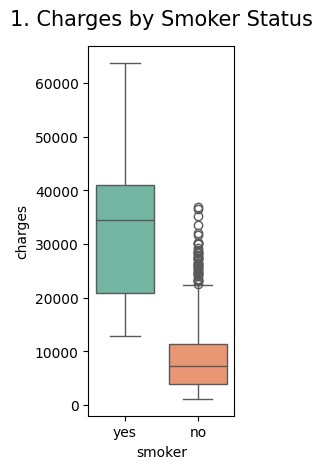

In [36]:
plt.subplot(1, 3, 1)
sns.boxplot(x='smoker', y='charges', data=insurance, palette='Set2')
plt.title('1. Charges by Smoker Status', fontsize=15, pad=15)

In [39]:
focus_cols = ['age', 'bmi', 'children', 'smoker_enc', 'sex_enc', 'charges', 'log_charges']

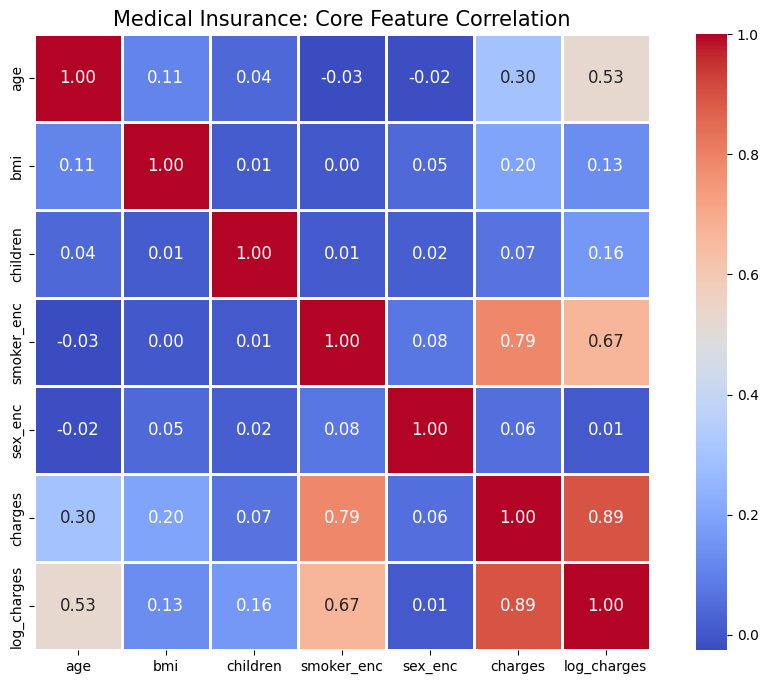

In [40]:
plt.figure(figsize=(12, 8))
core_corr = insurance[focus_cols].corr()

sns.heatmap(core_corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=1.0, annot_kws={"size": 12})

plt.title('Medical Insurance: Core Feature Correlation', fontsize=15)
plt.show()

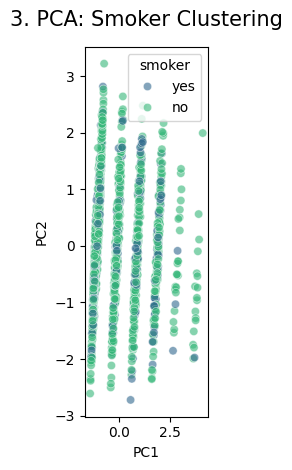

In [38]:
plt.subplot(1, 3, 3)
sns.scatterplot(x='PC1', y='PC2', hue='smoker', data=insurance, alpha=0.6, palette='viridis')
plt.title('3. PCA: Smoker Clustering', fontsize=15, pad=15)

plt.tight_layout(w_pad=5.0)
plt.show()

### File Save

In [41]:
output_path = '/content/drive/MyDrive/Colab Notebooks/insurance_cleaned.csv'
insurance.to_csv(output_path, index=False)